# Preprocessed Testing Datasets

| [![HOAPS-badge]][HOAPS-url] | [![hplp-badge]][hplp-url] | [![ICON-XPP-badge]][ICON-XPP-url] | [![NextGEMS-badge]][NextGEMS-url] | [![OpenIFS-badge]][OpenIFS-url] |
|:-:|:-:|:-:|:-:|:-:|

[HOAPS-badge]: https://img.shields.io/badge/HOAPS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[hplp-badge]: https://img.shields.io/badge/hplp-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[ICON-XPP-badge]: https://img.shields.io/badge/ICON--XPP-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[NextGEMS-badge]: https://img.shields.io/badge/NextGEMS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[OpenIFS-badge]: https://img.shields.io/badge/OpenIFS-grey?style=for-the-badge&logo=readthedocs&logoColor=white

[HOAPS-url]: https://climatedataguide.ucar.edu/climate-data/hoaps-hamburg-ocean-atmosphere-parameters-and-fluxes-satellite-data
[hplp-url]: https://apps.ecmwf.int/ifs-experiments/rd/hplp/
[ICON-XPP-url]: https://doi.org/10.5194/gmd-18-9385-2025
[NextGEMS-url]: https://easy.gems.dkrz.de/DYAMOND/NextGEMS/index.html
[OpenIFS-url]: https://confluence.ecmwf.int/spaces/OIFS/overview

We provide several datasets for this compression laboratory, which are introduced in this folder. We also include small testing subsets for each dataset, which have all been preprocessed to be in NetCDF4 format and on a regular latitude-longitude grid. These preprocessed datasets are used in the [compressor](../03-compressors/README.md) overview notebooks.

This notebook focuses on the small testing datasets. Please see the other notebooks for the original datasets and instructions [^report].

Here, we load all datasets using `xarray` and visualise them using our `quickplot(da)` helper function.

[^report]: Faghih-Naini, S., Tyree, J., Yepes-Arbós, X., Karsten, P. G., Dueben, P., & Järvinen, H. J. (2025). ESiWACE3 Deliverable D3.3 - Report on the online version of the data sets. *Zenodo*. Available from: [doi:10.5281/zenodo.14622238](https://doi.org/10.5281/zenodo.14622238).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import humanize
import numpy as np
import xarray as xr
from upath import UPath

In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

In [5]:
DATASET_PATHS = [
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_t_025deg_steps_2026-05_06.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_tp_025deg_steps_2026-05_06.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_pr_025deg_steps_44_45.nc",
    data / "OpenIFS" / "OpenIFS_pl_regridded_q_025deg_steps_114_120_levels_100_1000.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_t_025deg_steps_114_120.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_tp_025deg_steps_114_120.nc",
    data / "hplp" / "hplp_ml_regridded_q_025deg_levels_10_137_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_tp_025deg_steps_228_240.nc",
]

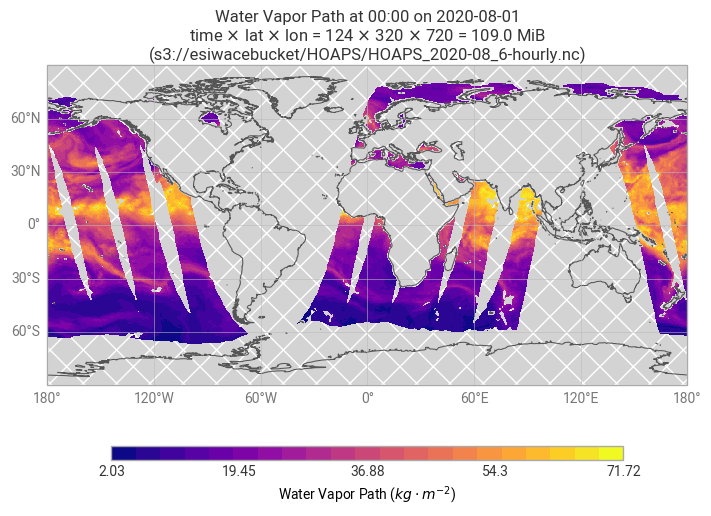

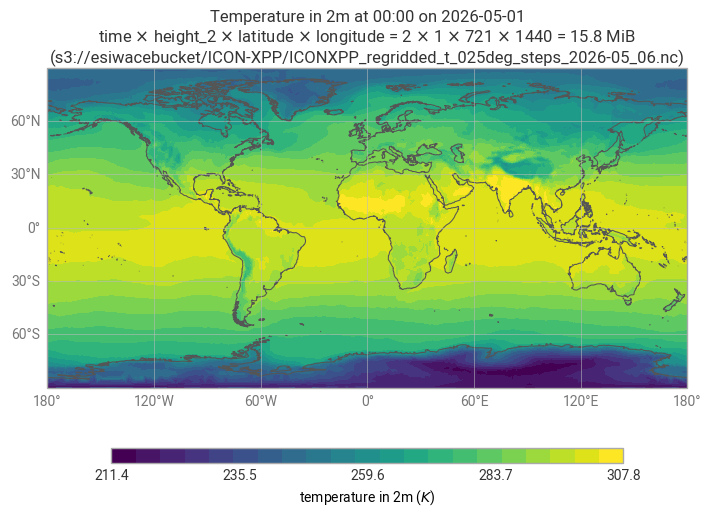

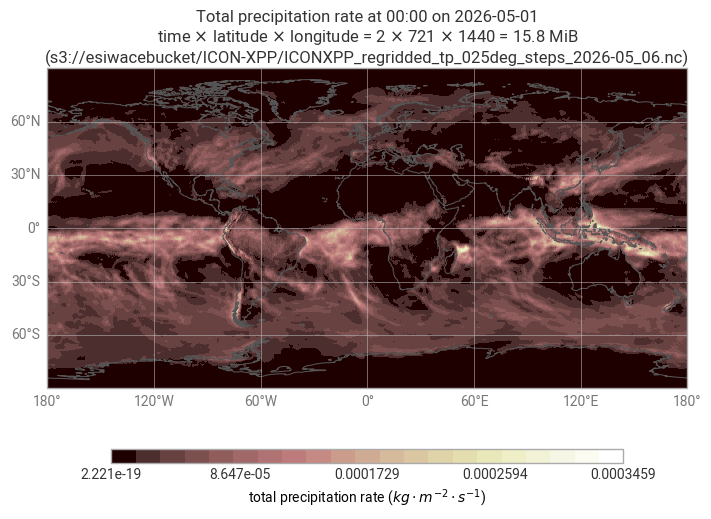

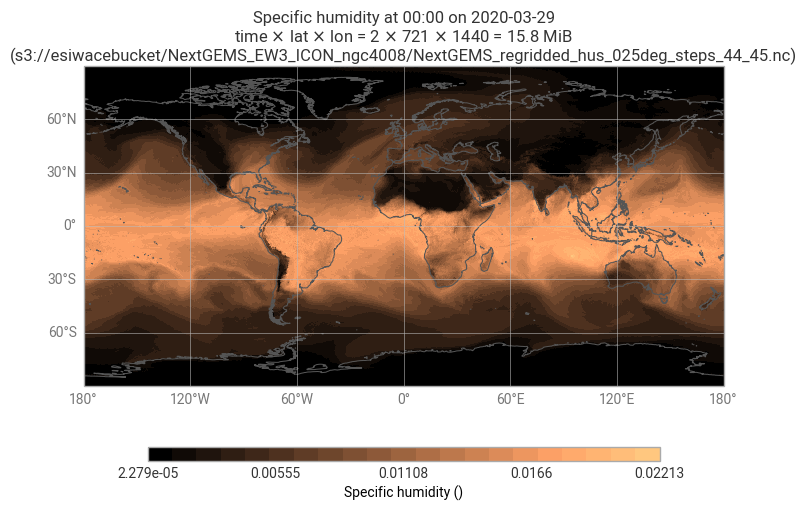

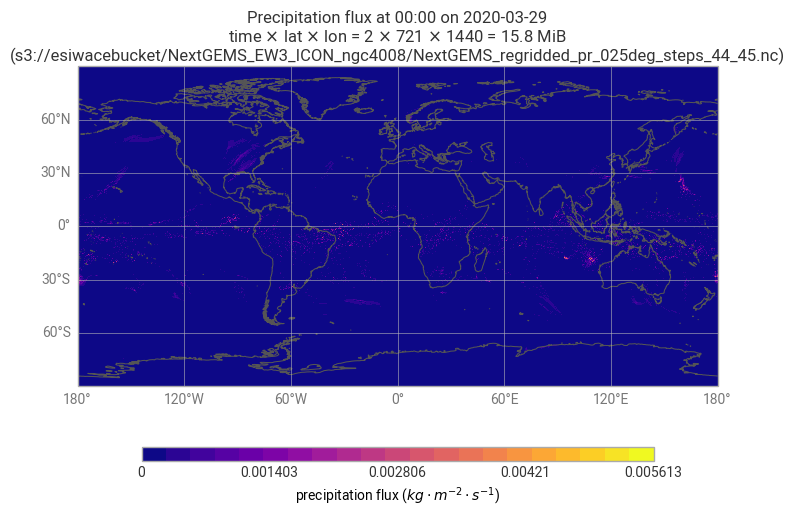

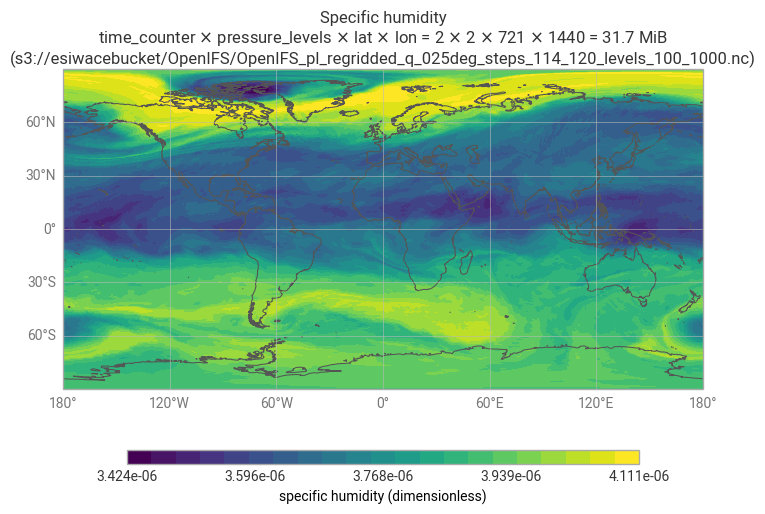

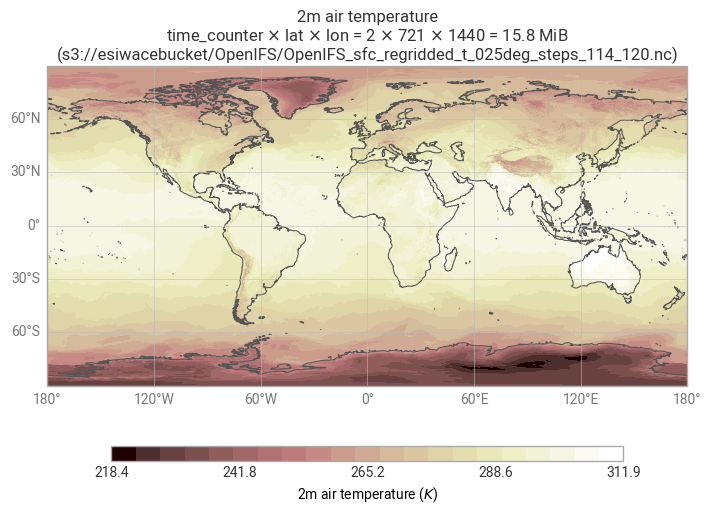

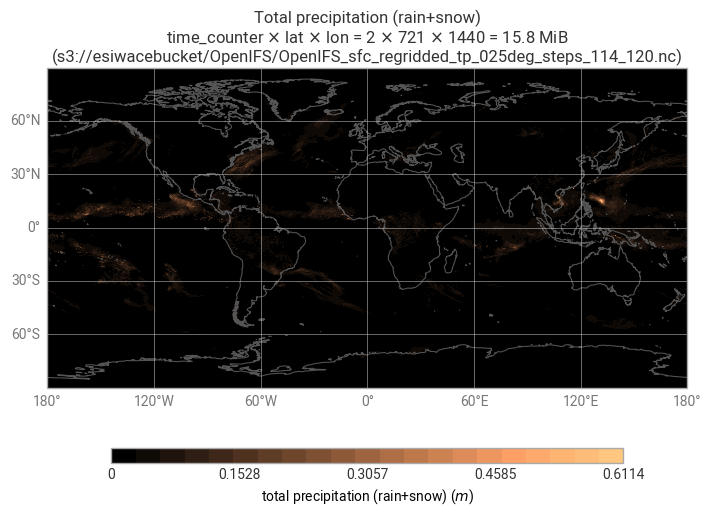

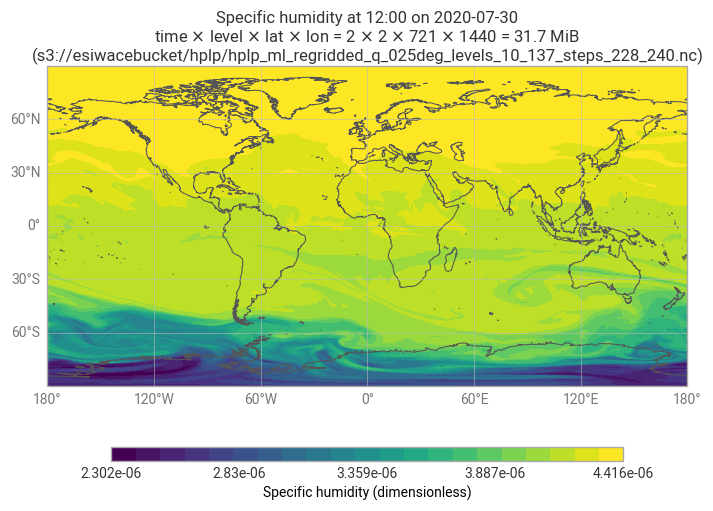

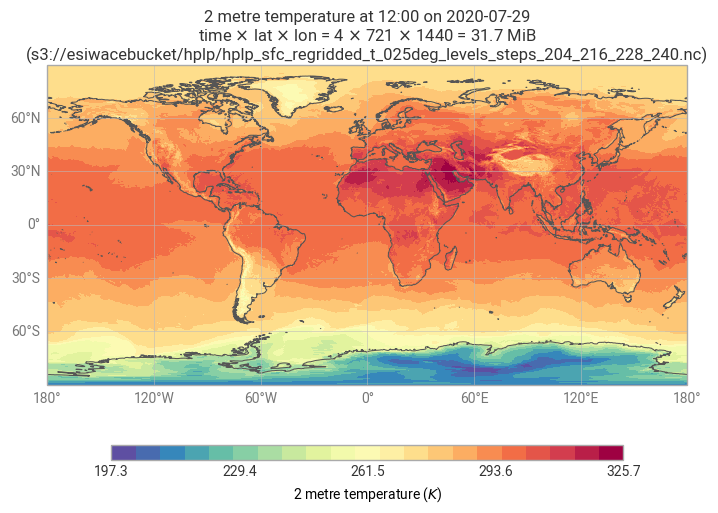

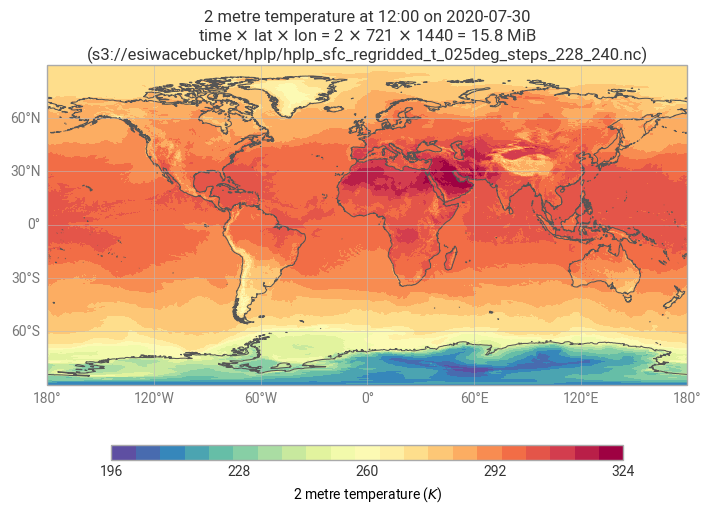

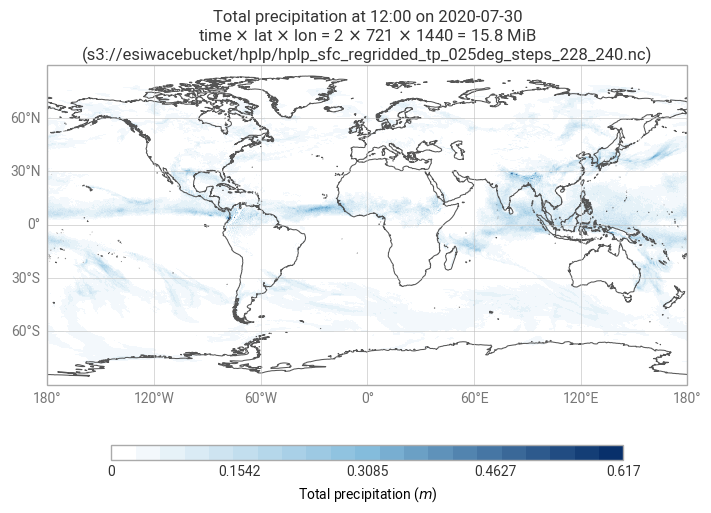

In [7]:
for path in DATASET_PATHS:
    # all example datasets are regridded to regular latitude-longitude grids in NetCDF4 format
    ds = open_remote_dataset(path, engine="h5netcdf", decode_timedelta=True)
    # most example datasets only contain a single variable
    if "HOAPS" in path.parent.name == "HOAPS":
        var = "wvpa"
    else:
        (var,) = list(ds)
    da = ds[var]

    quickplot(
        da,
        title=(
            "{default_title}"
            + (
                f"\n{r' $\times$ '.join(da.dims)} = "
                + f"{r' $\times$ '.join(str(s) for s in da.shape)} = "
                + f"{humanize.naturalsize(da.nbytes, binary=True)}"
            )
            + f"\n(s3://esiwacebucket/{path.relative_to(data)})"
        ),
    )